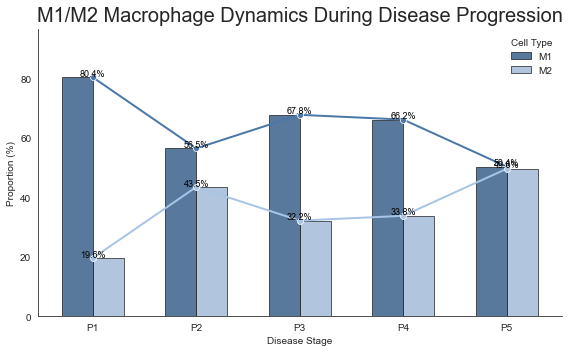

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1️⃣ JCC风格基础设置
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.linewidth": 0.8
})

sns.set_style("white")

# =========================
# 2️⃣ 读取数据
# =========================
df = pd.read_csv(
    r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv",
    encoding='gbk'
)

# =========================
# 3️⃣ Stage映射
# =========================
stage_map = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5"
}
df["Stage"] = df["标签"].map(stage_map)

# =========================
# 4️⃣ ROI过滤
# =========================
mask = (
    ((df["标签"] == "T004") & (df["子标签"].isin(["ROI008", "ROI009", "ROI010"]))) |
    ((df["标签"] == "T002") & (df["子标签"].isin(["ROI024"]))) |
    (~df["标签"].isin(["T004", "T002"]))
)

df_filtered = df[mask].copy()

# =========================
# 5️⃣ 仅保留 M1 / M2
# =========================
df_filtered = df_filtered[df_filtered["cell_type"].isin(["M1", "M2"])]

# =========================
# 6️⃣ 统计比例
# =========================
count_df = df_filtered.groupby(["Stage", "cell_type"]).size().reset_index(name="count")
total = count_df.groupby("Stage")["count"].transform("sum")
count_df["percent"] = count_df["count"] / total * 100

# Stage顺序
stage_order = ["P1", "P2", "P3", "P4", "P5"]
count_df["Stage"] = pd.Categorical(count_df["Stage"], categories=stage_order, ordered=True)

# =========================
# 7️⃣ 🎨 JCC heatmap同风格配色（重点修改）
# =========================
palette = {
    "M1": "#4C78A8",   # 深科研蓝（heatmap主色系）
    "M2": "#A9C5E5"    # 浅科研蓝（同色系弱化）
}

# =========================
# 8️⃣ 作图
# =========================
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=count_df,
    x="Stage",
    y="percent",
    hue="cell_type",
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    width=0.6
)

sns.lineplot(
    data=count_df,
    x="Stage",
    y="percent",
    hue="cell_type",
    marker="o",
    linewidth=2,
    palette=palette,
    legend=False,
    ax=ax
)

# =========================
# 9️⃣ 数值标注
# =========================
for _, row in count_df.iterrows():
    ax.text(
        row["Stage"],
        row["percent"] + 0.4,
        f"{row['percent']:.1f}%",
        ha="center",
        fontsize=9,
        color="black"
    )

# =========================
# 🔟 标题（保留）
# =========================
ax.set_title(
    "M1/M2 Macrophage Dynamics During Disease Progression",
    fontsize=20,
    pad=8
)

ax.set_xlabel("Disease Stage")
ax.set_ylabel("Proportion (%)")

# =========================
# 11️⃣ JCC风格轴
# =========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(axis='both', direction='out', length=3, width=0.8)

ax.legend(title="Cell Type", frameon=False)

ax.set_ylim(0, count_df["percent"].max() * 1.2)

#plt.savefig(
 # =========================
# 📁 输出保存（必须在 show 之前）
# =========================

plt.tight_layout()

plt.savefig(
    "Fig2a_M1_M2_stage_proportion.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Fig2a_M1_M2_stage_proportion.pdf",
    bbox_inches="tight"
)

plt.show()

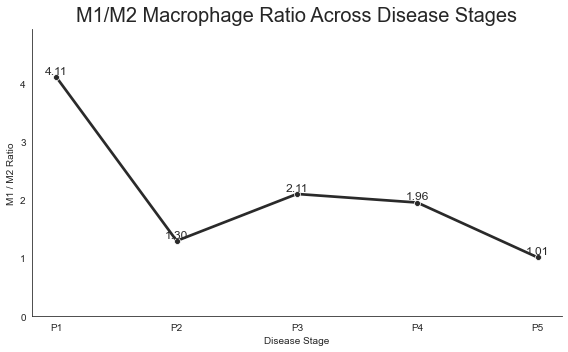

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1️⃣ JCC风格基础设置
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.linewidth": 0.8
})

sns.set_style("white")

# =========================
# 2️⃣ 读取数据
# =========================
df = pd.read_csv(
    r"C:\Users\Li Chujia\Desktop\cell_annotationV2\annotated_cells_mixed.csv",
    encoding='gbk'
)

# =========================
# 3️⃣ Stage映射
# =========================
stage_map = {
    "T005": "P1",
    "T006": "P2",
    "T001": "P3",
    "T002": "P4",
    "T004": "P5"
}
df["Stage"] = df["标签"].map(stage_map)

# =========================
# 4️⃣ ROI过滤
# =========================
mask = (
    ((df["标签"] == "T004") & (df["子标签"].isin(["ROI008", "ROI009", "ROI010"]))) |
    ((df["标签"] == "T002") & (df["子标签"].isin(["ROI024"]))) |
    (~df["标签"].isin(["T004", "T002"]))
)

df_filtered = df[mask].copy()

# =========================
# 5️⃣ 仅保留 M1 / M2
# =========================
df_filtered = df_filtered[df_filtered["cell_type"].isin(["M1", "M2"])]

# =========================
# 6️⃣ 计算 M1 / M2 ratio
# =========================
count_df = df_filtered.groupby(["Stage", "cell_type"]).size().unstack(fill_value=0)

count_df["M1/M2_ratio"] = count_df["M1"] / count_df["M2"].replace(0, pd.NA)

# =========================
# 7️⃣ stage顺序
# =========================
stage_order = ["P1", "P2", "P3", "P4", "P5"]
count_df = count_df.reindex(stage_order)

# =========================
# 8️⃣ 作图（JCC风格）
# =========================
plt.figure(figsize=(8, 5))

ax = sns.lineplot(
    x=count_df.index,
    y=count_df["M1/M2_ratio"],
    marker="o",
    linewidth=2.7,
    color="#2A2A2A"   # JCC常用深灰黑（比纯黑更高级）
)

# =========================
# 9️⃣ 数值标注
# =========================
for x, y in zip(count_df.index, count_df["M1/M2_ratio"]):
    if pd.notna(y):
        plt.text(
            x,
            y + 0.05,
            f"{y:.2f}",
            ha="center",
            fontsize=12,
            color="#2A2A2A"
        )

# =========================
# 🔟 标题（统一风格）
# =========================
plt.title(
    "M1/M2 Macrophage Ratio Across Disease Stages",
    fontsize=20,
    pad=8
)

plt.xlabel("Disease Stage")
plt.ylabel("M1 / M2 Ratio")

# =========================
# 11️⃣ JCC边框（只保留 left + bottom）
# =========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(axis='both', direction='out', length=3, width=0.8)

# =========================
# 12️⃣ y轴优化（避免比例失真）
# =========================
ax.set_ylim(0, count_df["M1/M2_ratio"].max() * 1.2)

# =========================
# 13️⃣ 输出
# =========================
plt.tight_layout()

plt.savefig(
    "Fig2b_M1M2_ratio.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Fig2b_M1M2_ratio.pdf",
    bbox_inches="tight"
)

plt.show()